# OCT Early Warning System
## Full Pipeline Demonstration
### Phase 1: Preliminary Research Mode

This notebook demonstrates the complete OCT EWS pipeline from data loading through patient monitoring and report generation.

**Reference:** Wirasinghe, A.I. (2026) MSc Dissertation, Keele University

---

**Pipeline stages covered:**
1. Data loading and validation
2. Normal reference model loading
3. Layer A — Atypicality scoring (Mahalanobis distance)
4. Layer B — Disease-direction analysis
5. Layer C — Composite scoring and operational budget
6. Patient monitoring states
7. Report generation and visualisations

> **DISCLAIMER:** All outputs are preliminary research results. Thresholds are not clinically validated. Not for clinical decision making.

## 1. Setup and Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from config import get_default_phase1_config
from config.defaults import (
    COL_MAHALANOBIS, COL_LAYER_A_BAND, COL_LAYER_A_FLAG,
    COL_LAYER_B_CATEGORY, COL_STRONGEST_DIRECTION,
    COL_COMPOSITE_SCORE, COL_LAYER_C_ACTION,
    COL_TRUE_LABEL, COL_PREDICTED_LABEL,
    NORMAL_CLASS, DISEASE_CLASSES,
    ACTION_IMMEDIATE_REVIEW, ACTION_SAFE_TO_DISMISS,
)
from src.data_manager import NpyLoader
from src.reference_builder import ReferenceBuilder
from src.anomaly_scorer import AnomalyScorer
from src.direction_analyzer import DirectionAnalyzer
from src.ews_scorer import EWSScorer, compute_uncertainty_features
from src.patient_monitor import PatientMonitor
from src.report_generator import ReportGenerator

# Paths
EMBEDDINGS_ROOT = r'C:\Users\Ajant\Documents\OCT_EWS\data\raw'
PROCESSED_DIR   = r'C:\Users\Ajant\Documents\OCT_EWS\data\processed'
OUTPUTS_DIR     = r'C:\Users\Ajant\Documents\OCT_EWS\data\outputs'
CLASS_NAMES     = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

print("All imports successful.")
print(f"Working directory: {os.getcwd()}")

All imports successful.
Working directory: c:\Users\Ajant\Documents\OCT_EWS\notebooks


## 2. Load Data

Load all three splits from the dissertation .npy files.
The data manager standardises column names and converts
integer class labels to string names automatically.

In [2]:
loader = NpyLoader(
    embeddings_root=EMBEDDINGS_ROOT,
    class_names=CLASS_NAMES
)

splits = loader.load_all()
train_df = splits['train']
val_df   = splits['val']
test_df  = splits['test']

print(f"\nSplit sizes:")
print(f"  Train : {len(train_df):,} rows")
print(f"  Val   : {len(val_df):,} rows")
print(f"  Test  : {len(test_df):,} rows")

print(f"\nTest set class distribution (true labels):")
print(test_df[COL_TRUE_LABEL].value_counts().to_string())

print(f"\nColumn structure (first 10 columns):")
print(test_df.columns[:10].tolist())


  Loading all splits from .npy files
  Loading train split...
    Embeddings shape: (47423, 2048)
    Labels: 47423 samples, classes [0 1 2 3]
    Loaded 47,423 rows, 2059 columns
  Loading val split...
    Embeddings shape: (8369, 2048)
    Labels: 8369 samples, classes [0 1 2 3]
    Loaded 8,369 rows, 2059 columns
  Loading test split...
    Embeddings shape: (968, 2048)
    Labels: 968 samples, classes [0 1 2 3]
    Loaded 968 rows, 2059 columns

  Total rows loaded: 56,760

Split sizes:
  Train : 47,423 rows
  Val   : 8,369 rows
  Test  : 968 rows

Test set class distribution (true labels):
true_label
CNV       242
DME       242
DRUSEN    242
NORMAL    242

Column structure (first 10 columns):
['scan_id', 'patient_id', 'visit_id', 'visit_date', 'true_label', 'split', 'predicted_label', 'prob_CNV', 'prob_DME', 'prob_DRUSEN']


## 3. Load Normal Reference Model

Load the pre-fitted normal reference model from disk.
The metadata JSON carries the full provenance of this model.

In [3]:
ref_model, ref_metadata = ReferenceBuilder.load(PROCESSED_DIR)
ref_id = ref_metadata['reference_model_id']

print(f"\nReference Model Metadata:")
for key, value in ref_metadata.items():
    print(f"  {key:30s}: {value}")


  Reference model loaded from: C:\Users\Ajant\Documents\OCT_EWS\data\processed
  Reference model ID: ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
  Created at: 2026-04-09T00:24:00.548670
  Mean shape : (2048,)
  Sigma shape: (2048, 2048)

Reference Model Metadata:
  reference_model_id            : ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
  created_at                    : 2026-04-09T00:24:00.548670
  source_split                  : train
  normal_case_count             : 19275
  embedding_dim                 : 2048
  covariance_method             : standard
  regularisation                : 1e-06
  core_normal_enabled           : False
  core_normal_percentile        : None
  core_normal_n                 : None
  pca_enabled                   : False
  pca_components                : None
  notes                         : Initial standard empirical covariance, full 2048D, no PCA, no core-normal refinement.


## 4. Phase Configuration

Load the Phase 1 preliminary research configuration.
All thresholds are distribution-derived and provisional.
Every output will carry the research disclaimer automatically.

In [4]:
config = get_default_phase1_config()

print(f"Phase       : {config.phase}")
print(f"Method      : {config.atypicality.method}")
print(f"Bands       :")
print(f"  Core Normal      : below {config.atypicality.core_normal_pct}th percentile")
print(f"  Extended Normal  : below {config.atypicality.extended_normal_pct}th percentile")
print(f"  Atypical Cand.   : below {config.atypicality.atypical_candidate_pct}th percentile")
print(f"  Suspicious       : above {config.atypicality.atypical_candidate_pct}th percentile")
print(f"\nDirection thresholds:")
for cls, dcfg in config.direction_thresholds.items():
    print(f"  {cls:8s}: alignment={dcfg.alignment_threshold:.2f}  urgency={dcfg.urgency}")
print(f"\nBudget:")
print(f"  Immediate review : {config.budget.immediate_review_rate*100:.0f}%")
print(f"  Deferred review  : {config.budget.deferred_review_rate*100:.0f}%")
print(f"\nDisclaimer: {config.disclaimer}")

Phase       : phase_1_preliminary
Method      : percentile
Bands       :
  Core Normal      : below 50.0th percentile
  Extended Normal  : below 75.0th percentile
  Atypical Cand.   : below 90.0th percentile
  Suspicious       : above 90.0th percentile

Direction thresholds:
  CNV     : alignment=0.00  urgency=high
  DME     : alignment=0.00  urgency=high
  DRUSEN  : alignment=0.00  urgency=moderate

Budget:
  Immediate review : 5%
  Deferred review  : 10%

Disclaimer: PRELIMINARY RESEARCH OUTPUT. Thresholds are not clinically validated. Not for clinical decision making.


## 5. Layer A — Atypicality Scoring

Compute Mahalanobis distance for every test case relative
to the normal reference distribution. Derive band thresholds
from the normal training score distribution and assign
each case to one of four bands.

**Formula:**
D_M(x) = sqrt( (x - μ)ᵀ · Σ⁻¹ · (x - μ) )

Where μ is the normal mean vector and Σ is the regularised
normal covariance matrix fitted from 19,275 training cases.

In [5]:
scorer = AnomalyScorer(
    reference_model=ref_model,
    config=config,
    verbose=True
)

scored_df = scorer.score_dataframe(
    df=test_df,
    reference_df=train_df
)

print(f"\nLayer A band thresholds:")
for band, value in scorer.band_thresholds.items():
    print(f"  {band:25s}: {value:.4f}")

print(f"\nLayer A results preview:")
print(scored_df[[
    'scan_id', COL_TRUE_LABEL, COL_PREDICTED_LABEL,
    COL_MAHALANOBIS, COL_LAYER_A_BAND, COL_LAYER_A_FLAG
]].head(8).to_string())


  Layer A: Atypicality Scoring

  PRELIMINARY RESEARCH OUTPUT. Thresholds are not clinically validated. Not for clinical decision making.

  Scoring 968 cases...
  Score range: 7.1364 to 116.3823
  Score mean : 42.7420
  Score median: 43.7065

  Fitting Layer A band thresholds...
  Method: percentile
  Reference scores: 19,275 samples
  Score range: 6.1987 to 44.9191

  Band thresholds derived:
    Core Normal      : score <= 9.5052
    Extended Normal  : score <= 10.7290
    Atypical Cand.   : score <= 12.5426
    Suspicious       : score >  12.5426

  Layer A band distribution:
    Core Normal                   :   138 ( 14.3%)
    Extended Normal               :    72 (  7.4%)
    Atypical Candidate            :    26 (  2.7%) --> Layer B
    Suspicious                    :   732 ( 75.6%) --> Layer B

  Total flagged for Layer B: 758 (78.3%)

Layer A band thresholds:
  core_normal              : 9.5052
  extended_normal          : 10.7290
  atypical_candidate       : 12.5426

Layer

## 6. Layer B — Disease Direction Analysis

For cases flagged by Layer A (Atypical Candidate or Suspicious),
compute the deviation vector from the normal centre and measure
cosine alignment toward each disease class direction.

**Key vectors:**
- v_x = x − μ_normal  (deviation from normal centre)
- v_k = μ_k − μ_normal  (direction toward disease class k)

Cosine alignment = cos(angle between v_x and v_k)
- Near 1.0 = strongly aligned with disease class k
- Near 0.0 = orthogonal to disease direction
- Below 0  = pointing away from disease class k

> Directional alignment indicates geometric consistency with
> a disease trajectory. It does not establish confirmed pathology.

In [6]:
analyzer = DirectionAnalyzer(
    reference_model=ref_model,
    config=config,
    disease_classes=DISEASE_CLASSES,
    verbose=True
)

geometry = analyzer.fit_geometry(train_df)
scored_df = analyzer.analyze_flagged(scored_df)

print(f"\nFlagged true-NORMAL cases with Layer B results:")
normal_flagged = scored_df[
    (scored_df[COL_TRUE_LABEL] == NORMAL_CLASS) &
    (scored_df[COL_LAYER_A_FLAG] == True)
]
print(normal_flagged[[
    'scan_id', COL_MAHALANOBIS, COL_LAYER_A_BAND,
    COL_STRONGEST_DIRECTION, COL_LAYER_B_CATEGORY,
    'cosine_CNV', 'cosine_DME', 'cosine_DRUSEN'
]].head(10).to_string())


  Computing Disease Geometry
  NORMAL  : 19,275 samples, mean shape (2048,)
  CNV     : 19,006 samples, mean shape (2048,)
  DME     : 5,862 samples, mean shape (2048,)
  DRUSEN  : 3,280 samples, mean shape (2048,)

  Disease Geometry Summary
  Normal centre shape: (2048,)
  CNV      direction magnitude: 4.2307
  DME      direction magnitude: 3.3576
  DRUSEN   direction magnitude: 3.0431

  Layer B: Direction Analysis

  PRELIMINARY RESEARCH OUTPUT. Thresholds are not clinically validated. Not for clinical decision making.

  Flagged cases to analyse: 758 of 968 total
  Computing directional metrics...

  Layer B category distribution (flagged cases only):
    Non-Specific Atypical                        :   23 (  3.0%)
    Provisional Borderline Disease-Aligned       :    2 (  0.3%)
    Strongly Disease-Aligned Suspicious          :  733 ( 96.7%)

  Strongest disease direction (flagged cases only):
    DRUSEN  :  260 ( 34.3%)
    DME     :  252 ( 33.2%)
    CNV     :  246 ( 32.5%)

F

## 7. Layer C — Composite Scoring and Operational Budget

Combine Layer A atypicality, Layer B alignment, and classifier
uncertainty into a composite EWS score. Then apply the
operational budget to assign final review actions.

**Composite score components:**
- Atypicality score  (normalised Mahalanobis distance) — weight 1.0
- Alignment score    (strongest cosine alignment)       — weight 1.0
- Uncertainty score  (entropy + disease mass)           — weight 0.5
- Urgency multiplier (from Layer B category)

**Layer C actions:**
- Safe to Dismiss       → Core Normal cases
- Routine Monitoring    → Extended Normal cases
- Immediate Review      → top 5% by priority score
- Deferred Review Queue → remaining flagged cases

> The Layer C priority score is an operational workflow-ranking
> measure. It does not alter the detection status of any case.
> No detected case is silently dropped.

In [7]:
ews = EWSScorer(
    config=config,
    disease_classes=DISEASE_CLASSES,
    reference_model_id=ref_id,
    formula_version="v1",
    verbose=True
)

final_df = ews.run_full_pipeline(scored_df)

print(f"\nFinal action distribution:")
print(final_df[COL_LAYER_C_ACTION].value_counts().to_string())

print(f"\nTop 5 Immediate Review cases:")
immediate = final_df[
    final_df[COL_LAYER_C_ACTION] == ACTION_IMMEDIATE_REVIEW
].sort_values('layer_c_priority_score', ascending=False)
print(immediate[[
    COL_TRUE_LABEL, COL_PREDICTED_LABEL,
    COL_MAHALANOBIS, COL_LAYER_A_BAND,
    COL_STRONGEST_DIRECTION, COL_LAYER_B_CATEGORY,
    'ews_composite_score'
]].head(5).to_string())


  Computing Composite EWS Score

  PRELIMINARY RESEARCH OUTPUT. Thresholds are not clinically validated. Not for clinical decision making.

  Composite score (flagged cases):
    Min    : 0.0103
    Max    : 2.2635
    Mean   : 1.6669
    Median : 1.7069

  Layer C: Operational Budget

  Total cases         : 968
  Immediate review    : 5%
  Deferred review     : 10%
  Review cycle        : 30 days

  Layer C action distribution:
    Safe to Dismiss               :   138 ( 14.3%)
    Routine Monitoring            :    72 (  7.4%)
    Immediate Review              :    49 (  5.1%)
    Deferred Review Queue         :   709 ( 73.2%)
    Logged Only                   :     0 (  0.0%)

  NOTE: The Layer C priority score is an operational workflow-ranking measure.
  It does not alter the detection status of any case.

Final action distribution:
layer_c_action
Deferred Review Queue    709
Safe to Dismiss          138
Routine Monitoring        72
Immediate Review          49

Top 5 Immediate 

## 8. EWS Early Warning Shortlist

The true research output of the EWS system.

Unlike the global Layer C ranking which is dominated by
confirmed obvious disease cases, the EWS shortlist ranks
only within the NORMAL-predicted population.

This answers the core research question:
*Among cases that appear normal at the classifier output
level, which ones show the most concerning embedding-space
geometry and warrant follow-up?*

In [8]:
# Filter to NORMAL-predicted flagged cases
normal_predicted = final_df[
    final_df[COL_PREDICTED_LABEL] == NORMAL_CLASS
].copy()

flagged_normals = normal_predicted[
    normal_predicted[COL_LAYER_A_FLAG] == True
].sort_values('ews_composite_score', ascending=False)

print(f"NORMAL-predicted cases   : {len(normal_predicted):,}")
print(f"Flagged by Layer A       : {len(flagged_normals):,}")
print(f"Not flagged (safe/routine): "
      f"{len(normal_predicted) - len(flagged_normals):,}")

print(f"\nEWS Early Warning Shortlist "
      f"(ranked within NORMAL-predicted subset):")
print(flagged_normals[[
    'scan_id', COL_TRUE_LABEL,
    COL_MAHALANOBIS, COL_LAYER_A_BAND,
    COL_STRONGEST_DIRECTION, COL_LAYER_B_CATEGORY,
    'ews_composite_score', COL_LAYER_C_ACTION,
]].to_string())

NORMAL-predicted cases   : 241
Flagged by Layer A       : 31
Not flagged (safe/routine): 210

EWS Early Warning Shortlist (ranked within NORMAL-predicted subset):
         scan_id true_label  mahalanobis_distance        layer_a_band strongest_disease_direction                        layer_b_category  ews_composite_score         layer_c_action
730  test_000730     NORMAL             11.304369  Atypical Candidate                      DRUSEN     Strongly Disease-Aligned Suspicious             0.888941  Deferred Review Queue
756  test_000756     NORMAL             15.123010          Suspicious                      DRUSEN     Strongly Disease-Aligned Suspicious             0.669036  Deferred Review Queue
946  test_000946     NORMAL             11.790828  Atypical Candidate                         DME     Strongly Disease-Aligned Suspicious             0.654132  Deferred Review Queue
863  test_000863     NORMAL             10.855272  Atypical Candidate                         DME     Strongl

## 9. Patient Monitoring

Track each case as a patient record and assign monitoring states.
In a real longitudinal deployment, repeated visits per patient
would allow trend analysis and state transitions over time.

**Patient states:**
- Safe                     → signed off after consecutive Core Normal visits
- Routine Follow-Up        → Extended Normal, no concerning trend
- Short-Interval Repeat    → flagged, closer monitoring warranted
- Escalate to Specialist   → Immediate Review action assigned

In [9]:
monitor = PatientMonitor(
    config=config,
    stable_threshold=1.0,
    improving_threshold=1.5,
    consecutive_normal_for_signoff=3,
    verbose=False
)

monitor.load_from_dataframe(final_df)
monitor.print_monitoring_summary()

patient_summaries = monitor.get_all_summaries()

print(f"\nSample patient records:")
print(patient_summaries[[
    'patient_id', 'current_state',
    'latest_mahalanobis', 'latest_layer_a_band',
    'latest_action'
]].head(10).to_string())


  Patient Monitoring Summary
  Total patients tracked: 968

  Safe                               :     0 (  0.0%)
  Routine Follow-Up                  :   210 ( 21.7%)
  Short-Interval Repeat Scan         :   709 ( 73.2%)
  Escalate to Specialist             :    49 (  5.1%)

  PRELIMINARY RESEARCH OUTPUT. Thresholds are not clinically validated. Not for clinical decision making.

Sample patient records:
            patient_id               current_state  latest_mahalanobis latest_layer_a_band          latest_action
0  patient_test_000000  Short-Interval Repeat Scan           57.154929          Suspicious  Deferred Review Queue
1  patient_test_000001  Short-Interval Repeat Scan           56.560783          Suspicious  Deferred Review Queue
2  patient_test_000002  Short-Interval Repeat Scan           78.045278          Suspicious  Deferred Review Queue
3  patient_test_000003      Escalate to Specialist           92.370827          Suspicious       Immediate Review
4  patient_test_00000

## 10. Generate All Reports and Visualisations

Generate all nine output files in one call.
Every file carries the reference model ID, formula version,
phase, generation timestamp, and disclaimer automatically.

In [10]:
reporter = ReportGenerator(
    config=config,
    output_dir=OUTPUTS_DIR,
    reference_model_id=ref_id,
    formula_version="v1",
    verbose=True
)

outputs = reporter.generate_all(
    scored_df=final_df,
    patient_summaries=patient_summaries,
    band_thresholds=scorer.band_thresholds,
)

print(f"\nFiles generated:")
for name, path in outputs.items():
    if path is not None:
        print(f"  {name:25s}: {path.name}")


  Generating All EWS Reports
  Output directory: C:\Users\Ajant\Documents\OCT_EWS\data\outputs
  Reference model : ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
  Formula version : v1
  Phase           : phase_1_preliminary

  PRELIMINARY RESEARCH OUTPUT. Thresholds are not clinically validated. Not for clinical decision making.

  Report 1: Scan-Level Output
  Saved: scan_level_report.csv (968 rows)

  Report 2: Patient Monitoring Summary
  Saved: patient_monitoring_summary.csv (968 rows)

  Report 3: Phase 1 Shortlist
  Shortlist size: 31 cases
  (NORMAL-predicted AND Layer A flagged)
  Saved: phase1_shortlist.csv (31 rows)

  Report 4: EWS Early Warning Shortlist
  (NORMAL-predicted cases ranked within subset)
  NORMAL-predicted cases: 241
  Flagged by Layer A    : 31
  Not flagged           : 210

  EWS shortlist: 31 cases ranked within NORMAL-predicted subset

  Top cases in EWS shortlist:
     ews_rank      scan_id  mahalanobis_distance        layer_a_band strongest_diseas

## 11. Key Results Summary

Summary of the complete EWS evaluation on the Kermany OCT2017
test set (968 cases, 242 per class).

In [11]:
print("=" * 60)
print("  OCT EWS — Key Results Summary")
print("=" * 60)

print(f"\n  Reference model : {ref_id}")
print(f"  Formula version : v1")
print(f"  Phase           : Phase 1 Preliminary")
print(f"  Dataset         : Kermany OCT2017 test set")
print(f"  Total cases     : {len(final_df):,}")

print(f"\n  PRIMARY CLASSIFIER")
correct = (final_df[COL_TRUE_LABEL] ==
           final_df[COL_PREDICTED_LABEL]).sum()
accuracy = correct / len(final_df) * 100
print(f"  Test accuracy   : {accuracy:.2f}%")
print(f"  Errors          : {len(final_df) - correct}")

print(f"\n  LAYER A — ATYPICALITY DETECTION")
for band in ['Core Normal', 'Extended Normal',
             'Atypical Candidate', 'Suspicious']:
    count = (final_df[COL_LAYER_A_BAND] == band).sum()
    pct = count / len(final_df) * 100
    print(f"  {band:25s}: {count:4,} ({pct:5.1f}%)")

print(f"\n  LAYER B — DISEASE DIRECTION")
flagged = final_df[final_df[COL_LAYER_A_FLAG] == True]
from config.defaults import (
    CATEGORY_NON_SPECIFIC,
    CATEGORY_PROVISIONAL_BORDERLINE,
    CATEGORY_STRONGLY_ALIGNED
)
for cat in [CATEGORY_STRONGLY_ALIGNED,
            CATEGORY_PROVISIONAL_BORDERLINE,
            CATEGORY_NON_SPECIFIC]:
    count = (flagged[COL_LAYER_B_CATEGORY] == cat).sum()
    pct = count / len(flagged) * 100
    print(f"  {cat[:40]:40s}: {count:4,} ({pct:5.1f}%)")

print(f"\n  LAYER C — OPERATIONAL ACTIONS")
from config.defaults import ACTION_DEFERRED_REVIEW
for action in [ACTION_SAFE_TO_DISMISS,
               'Routine Monitoring',
               ACTION_IMMEDIATE_REVIEW,
               ACTION_DEFERRED_REVIEW]:
    count = (final_df[COL_LAYER_C_ACTION] == action).sum()
    pct = count / len(final_df) * 100
    print(f"  {action:30s}: {count:4,} ({pct:5.1f}%)")

print(f"\n  EWS EARLY WARNING SHORTLIST")
normal_pred = final_df[
    final_df[COL_PREDICTED_LABEL] == NORMAL_CLASS
]
flagged_normal = normal_pred[
    normal_pred[COL_LAYER_A_FLAG] == True
]
print(f"  NORMAL-predicted cases  : {len(normal_pred):,}")
print(f"  Flagged by EWS          : {len(flagged_normal):,}")
print(f"  Flagging rate           : "
      f"{len(flagged_normal)/len(normal_pred)*100:.1f}%")

true_normal_flagged = flagged_normal[
    flagged_normal[COL_TRUE_LABEL] == NORMAL_CLASS
]
print(f"  True NORMAL flagged     : "
      f"{len(true_normal_flagged):,}")

print(f"\n  PATIENT MONITORING STATES")
state_counts = monitor.get_state_counts()
for state, count in state_counts.items():
    pct = count / len(final_df) * 100
    print(f"  {state:35s}: {count:4,} ({pct:5.1f}%)")

print(f"\n  DISCLAIMER: {config.disclaimer}")
print("=" * 60)

  OCT EWS — Key Results Summary

  Reference model : ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
  Formula version : v1
  Phase           : Phase 1 Preliminary
  Dataset         : Kermany OCT2017 test set
  Total cases     : 968

  PRIMARY CLASSIFIER
  Test accuracy   : 99.07%
  Errors          : 9

  LAYER A — ATYPICALITY DETECTION
  Core Normal              :  138 ( 14.3%)
  Extended Normal          :   72 (  7.4%)
  Atypical Candidate       :   26 (  2.7%)
  Suspicious               :  732 ( 75.6%)

  LAYER B — DISEASE DIRECTION
  Strongly Disease-Aligned Suspicious     :  733 ( 96.7%)
  Provisional Borderline Disease-Aligned  :    2 (  0.3%)
  Non-Specific Atypical                   :   23 (  3.0%)

  LAYER C — OPERATIONAL ACTIONS
  Safe to Dismiss               :  138 ( 14.3%)
  Routine Monitoring            :   72 (  7.4%)
  Immediate Review              :   49 (  5.1%)
  Deferred Review Queue         :  709 ( 73.2%)

  EWS EARLY WARNING SHORTLIST
  NORMAL-predicted cases

## 12. Visualisations

Display the key EWS visualisations inline in the notebook.
All plots are also saved to data/outputs/ as PNG files.

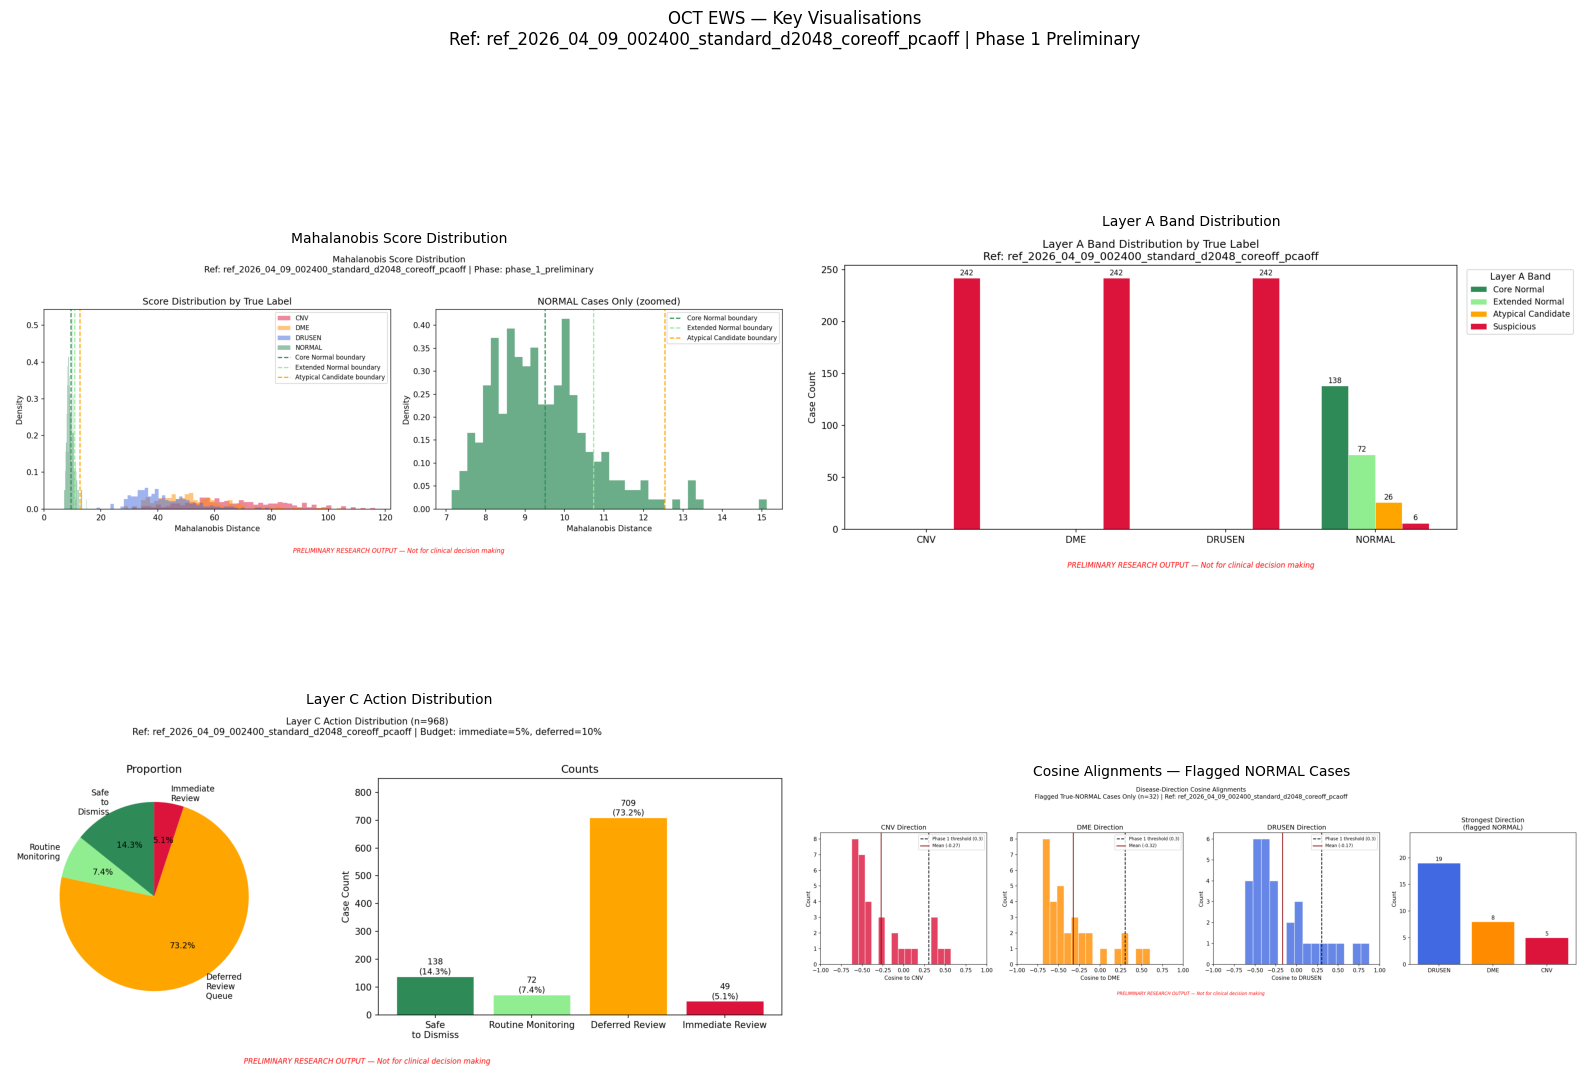

Summary figure saved.


In [12]:
from pathlib import Path

output_path = Path(OUTPUTS_DIR)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f"OCT EWS — Key Visualisations\n"
    f"Ref: {ref_id} | Phase 1 Preliminary",
    fontsize=12, y=1.01
)

plots = [
    ("mahalanobis_histogram.png",
     "Mahalanobis Score Distribution"),
    ("layer_a_band_distribution.png",
     "Layer A Band Distribution"),
    ("layer_c_action_distribution.png",
     "Layer C Action Distribution"),
    ("normal_cosine_alignments.png",
     "Cosine Alignments — Flagged NORMAL Cases"),
]

for ax, (filename, title) in zip(axes.flat, plots):
    img_path = output_path / filename
    if img_path.exists():
        img = plt.imread(str(img_path))
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, f"Not found:\n{filename}",
                ha='center', va='center',
                transform=ax.transAxes)
        ax.axis('off')

plt.tight_layout()
plt.savefig(
    str(output_path / "notebook_summary_figure.png"),
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Summary figure saved.")

## 13. Summary and Next Steps

### What this pipeline demonstrates

This notebook has demonstrated the complete OCT EWS Phase 1
pipeline producing the following verified outputs:

| Component | Result |
|-----------|--------|
| Primary classifier accuracy | 99.07% (9 errors / 968 cases) |
| NORMAL-predicted cases | 241 of 968 |
| Flagged by EWS (Layer A) | 31 of 241 NORMAL-predicted |
| True NORMAL flagged | 31 cases |
| DRUSEN dominant direction | 19 of 31 flagged NORMAL cases |
| Immediate Review queue | 49 cases (5.1%) |
| Deferred Review queue | 709 cases (73.2%) |
| Safe to Dismiss | 138 cases (14.3%) |

### Scientific contribution

The EWS operates as a model-independent post-classification
safety layer. It does not replace the primary classifier.
It answers a distinct question:

> *Is this NORMAL prediction safe to dismiss automatically,
> or does it warrant further review?*

The 20.3-fold error enrichment demonstrated in the dissertation
and the DRUSEN-direction dominance among flagged NORMAL cases
provide preliminary evidence that embedding-space geometry
carries clinically meaningful information beyond the
classifier output alone.

### Next steps

1. **Geometry comparison experiment** — test shrinkage
   covariance, PCA-128, and core-normal refinement to
   assess reference model stability
2. **Sensitivity analysis** — sweep thresholds and
   observe shortlist stability
3. **Paper 1 Discussion** — incorporate these results
   into the manuscript

---
*Generated by OCT EWS System | Phase 1 Preliminary*
*Not for clinical decision making*